# % of Bike Commuters vs Bike Network Quality (Connectivity of LTS < 2 Subnetwork)

In [1]:
%%capture
pip install osmnx

In [2]:
%%capture
pip install --pre pycen==0.1.0a4

In [96]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import networkx as nx
from pycen import acquire

plt.style.use('seaborn-v0_8')

city = ["San Jose","Berkeley",'Fremont','Santa Monica','Concord','Irvine','Mountain View','Palo Alto','San Rafael','Redondo Beach','Santa Clara','Santa Cruz','Santa Rosa','Oakland','San Francisco'] ### CHANGE THIS TO TRY OTHER CITIES. FIRST MAKE SURE THAT YOU HAVE DOWNLOADED THE QUALITY CSV FOR ALL OF THEM
#county= ['Santa Clara','Alameda'] #not used
state = "California"

PLACE = "%s, %s, USA"%(city,state)
YEARS = [2014, 2019] ### CHANGE THIS TO TRY OTHER YEARS
DATASET = "acs5"

variables = {
    "B08301_001E": "workers_total",
    "B08301_008E": "bike_commute"
}

print("Libraries imported.")

Libraries imported.


In [240]:
len(city)

15

## 1. Download ACS bike commute share for city tracts

We pull tract-level data for two years and compute the percentage of workers who commute by bicycle.

We are going to iterate over every city in the given list of cities above. For each city, we import the census data including bike ridership for the two given years, import the csv file with the corresponding network analysis, and merge into one dataframe by census tract id. Then, we concatenate the dataframe to a larger combined dataframe that includes all cities.

In [97]:
tracts=pd.DataFrame()
for c in city:
    tracts_by_year = []
    for year in YEARS:
        gdf = acquire.get_censhp(
            variables=variables,
            geography="tract",
            place="%s"%c,
            state="CA",
            year=year,
            dataset=DATASET,
            add_area=True
        )
        gdf.replace(-666666666, np.nan, inplace=True)
        gdf["pct_bike_%s"%year] = gdf["bike_commute"] / gdf["workers_total"] * 100
        #gdf["year"] = year
        gdf['city'] = c
        tracts_by_year.append(gdf.to_crs("EPSG:4326"))
    #tracts_by_year = gpd.GeoDataFrame(pd.concat(tracts_by_year, ignore_index=True), crs="EPSG:4326")
    
    gdf_2014=tracts_by_year[0].reset_index()
    gdf_2019=tracts_by_year[1].reset_index()
    
    tracts_c = gpd.GeoDataFrame(gdf_2014)
    
    pct_bike_yr1,pct_bike_yr2='pct_bike_%s'%YEARS[0],'pct_bike_%s'%YEARS[1]
    tracts_c=pd.merge(tracts_c,gdf_2019[['GEOID',pct_bike_yr2]],on='GEOID')

    tracts_c['GEOID']=tracts_c['GEOID'].astype('int') ## make sure the tract id is an int so it is possible to merge with network quality

    bike_network_quality = pd.read_csv('data/%s_network_quality_metrics.csv'%c) ## Import csv of bike quality metrics by census tract (calculated in other notebooks)

    common_columns = tracts_c.drop(['index',pct_bike_yr1,pct_bike_yr2, 'workers_total', 'bike_commute', 'area_sqkm','city'],axis=1).columns
    quality_variable_columns = bike_network_quality.drop(['B19001_001E','Unnamed: 0','nodes', 'edges', 'nodes_lts1', 'edges_lts1', 'nodes_lts2',
       'edges_lts2'],axis=1).drop(common_columns,axis=1).columns ## 3. Only inclue relevant unique columns from the network quality dataframe (don't need duplicated census geometry data)
    
    ridership_quality_combined = pd.merge(tracts_c,bike_network_quality[np.append(quality_variable_columns,'GEOID')], on='GEOID') #Merge all network quality columns to the ridership dataframe by tract id
    
    tracts =pd.concat([tracts,ridership_quality_combined]) ## Add all combined data (census + network quality) from this city to the dataframe with all cities
    
tracts['pct_change']=tracts[pct_bike_yr2]-tracts[pct_bike_yr1]
    
    #tracts=pd.merge(tracts,gdf_2019['pct_bike_2019'],on='')

Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2014_tract_06__07ae958225a92c0b.csv
Loading boundaries from cache...
Merging data...
Clipping to place: San Jose
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__60e657f1e70e8a23.csv
Loading boundaries from cache...
Merging data...
Clipping to place: San Jose
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2014_tract_06__07ae958225a92c0b.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__60e657f1e70e8a23.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Lo

In [206]:
tracts[quality_variable_columns]=tracts[quality_variable_columns].apply(lambda x: (x/max(np.abs(x))))

In [207]:
# nodes_in_tract = gpd.sjoin(
#     nodes_gdf,
#     tracts[["geometry"]],
#     how="inner",
#     predicate="within"
# )
# centrality_by_tract = nodes_in_tract.groupby("index_right")["betweenness"].mean()
# tracts["betweenness"] = centrality_by_tract
# tracts["betweenness"] = tracts["betweenness"].fillna(0)

# print(f"Tracts with centrality values: {tracts['betweenness'].gt(0).sum()} / {len(tracts)}")


## 4. Correlation Plot for all quality variables

In [208]:
import seaborn as sns

In [209]:
#correlation=ridership_quality_combined[np.append(quality_variable_columns,'pct_change')].corr()
#sns.heatmap(correlation)

In [210]:
#sns.set_theme(style="ticks")

#sns.pairplot(ridership_quality_combined[np.append(quality_variable_columns,'pct_change')])

<Axes: >

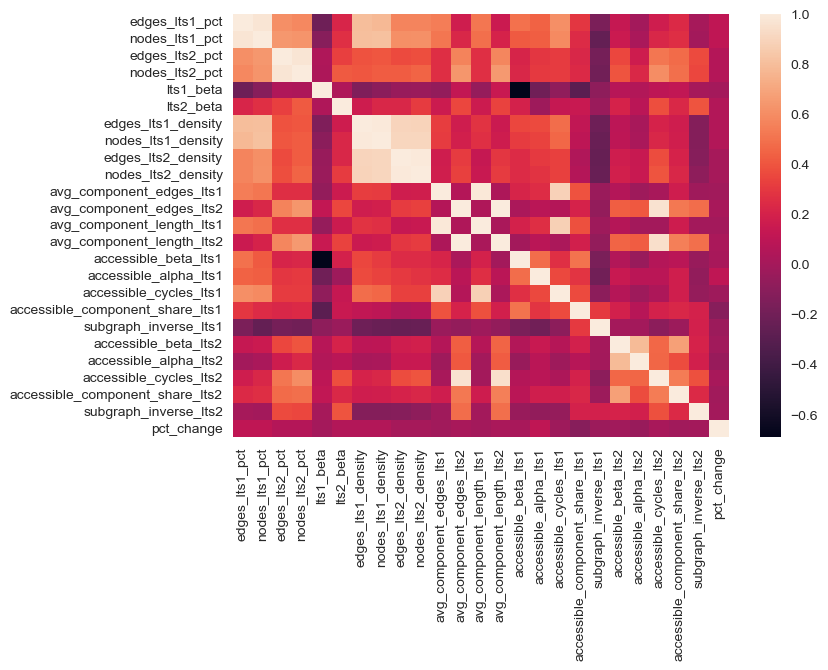

In [211]:
## I think the issue is that they all have too many 0 values
#filter out zero values

## Correlation with percentage change
ridership_quality_combined_nonzero=tracts[tracts[pct_bike_yr2]>0]
correlation=ridership_quality_combined_nonzero[np.append(quality_variable_columns,'pct_change')].corr()
sns.heatmap(correlation)

In [104]:
len(ridership_quality_combined_nonzero)

205

In [215]:
#highest correlation with percentage change
correlation['pct_change'].sort_values()

accessible_component_share_lts1   -0.110737
accessible_alpha_lts2             -0.049365
subgraph_inverse_lts1             -0.031539
accessible_cycles_lts1            -0.025009
avg_component_edges_lts1          -0.017602
accessible_beta_lts2              -0.016560
accessible_component_share_lts2   -0.015848
avg_component_length_lts1         -0.010444
subgraph_inverse_lts2             -0.007366
lts1_beta                          0.000399
edges_lts2_density                 0.003620
nodes_lts2_density                 0.006787
accessible_cycles_lts2             0.011293
accessible_beta_lts1               0.012255
avg_component_edges_lts2           0.012313
avg_component_length_lts2          0.017213
nodes_lts1_density                 0.050384
lts2_beta                          0.051047
edges_lts1_density                 0.053383
nodes_lts2_pct                     0.056446
edges_lts2_pct                     0.061406
accessible_alpha_lts1              0.102222
edges_lts1_pct                  

In [216]:
ridership_quality_combined_nonzero[np.append(quality_variable_columns,pct_bike_yr2)]

,edges_lts1_pct,nodes_lts1_pct,edges_lts2_pct,nodes_lts2_pct,lts1_beta,lts2_beta,edges_lts1_density,nodes_lts1_density,edges_lts2_density,nodes_lts2_density,...,accessible_alpha_lts1,accessible_cycles_lts1,accessible_component_share_lts1,subgraph_inverse_lts1,accessible_beta_lts2,accessible_alpha_lts2,accessible_cycles_lts2,accessible_component_share_lts2,subgraph_inverse_lts2,pct_bike_2019
2,0.246372,0.264155,0.483183,0.494448,0.026649,0.631723,0.185547,0.183749,0.327220,0.305598,...,0.140574,0.024793,0.331230,0.024390,0.916604,0.368080,0.015820,0.797733,0.018868,0.464481
5,0.147922,0.146794,0.375000,0.365647,0.024823,0.605766,0.095667,0.088247,0.218086,0.195306,...,0.052350,0.002361,0.378049,0.062500,0.960483,0.619485,0.162100,0.952777,0.020000,0.313480
9,0.150317,0.158973,0.362857,0.372964,0.026208,0.632624,0.101667,0.099014,0.220686,0.206398,...,0.128936,0.008264,0.896552,0.125000,0.951787,0.584926,0.021094,0.287885,0.052632,0.244648
11,0.094515,0.103576,0.408991,0.428731,0.027628,0.656387,0.042872,0.044016,0.166823,0.161882,...,0.027055,0.002361,0.419048,0.083333,0.936194,0.411954,0.090909,0.620616,0.026316,3.000000
13,0.036297,0.032925,0.311310,0.302091,0.022970,0.610322,0.019436,0.016590,0.149895,0.135248,...,0.068274,0.007084,0.844920,0.111111,0.933778,0.404096,0.040238,0.737800,0.035714,0.543478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,0.096047,0.115550,0.667947,0.638782,0.035714,0.705125,0.028571,0.037919,0.178669,0.186251,...,0.050829,0.003542,0.948413,0.166667,0.963961,0.627220,0.951393,0.999739,0.250000,1.043738
170,0.197496,0.190658,0.589286,0.551818,0.026515,0.638808,0.065025,0.064071,0.174468,0.164767,...,0.032833,0.002361,0.438462,0.083333,0.963855,0.626553,0.951049,0.999036,0.142857,0.723589
185,0.195131,0.118421,1.000000,0.993655,0.013441,0.546591,0.043188,0.021572,0.199024,0.160824,...,0.091119,0.016529,0.989264,0.200000,0.963910,0.626936,0.950820,0.999889,0.166667,0.705687
187,0.369954,0.352401,0.653627,0.629397,0.026639,0.668854,0.171139,0.169418,0.271892,0.268851,...,0.167863,0.145218,0.946774,0.058824,0.963661,0.626119,0.951049,0.998345,0.043478,0.769823


In [ ]:
#sns.pairplot(ridership_quality_combined_nonzero[np.append(quality_variable_columns,pct_bike_yr2)].reset_index())

In [218]:
## table of highest correlation with current ridership?
correlation_2=ridership_quality_combined_nonzero[np.append(quality_variable_columns,pct_bike_yr2)].corr()
correlation_2[pct_bike_yr2].sort_values()

accessible_cycles_lts1            -0.089327
nodes_lts2_density                -0.074093
edges_lts2_density                -0.072196
accessible_component_share_lts1   -0.064700
subgraph_inverse_lts2             -0.057820
avg_component_edges_lts1          -0.056826
accessible_cycles_lts2            -0.056757
avg_component_length_lts1         -0.054505
accessible_component_share_lts2   -0.052017
avg_component_edges_lts2          -0.050433
nodes_lts2_pct                    -0.047202
avg_component_length_lts2         -0.043704
accessible_alpha_lts2             -0.041501
edges_lts2_pct                    -0.039626
accessible_beta_lts2              -0.028686
edges_lts1_density                -0.015123
nodes_lts1_density                -0.014431
lts2_beta                         -0.006268
subgraph_inverse_lts1              0.001889
lts1_beta                          0.004955
accessible_beta_lts1               0.012699
edges_lts1_pct                     0.015995
nodes_lts1_pct                  

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

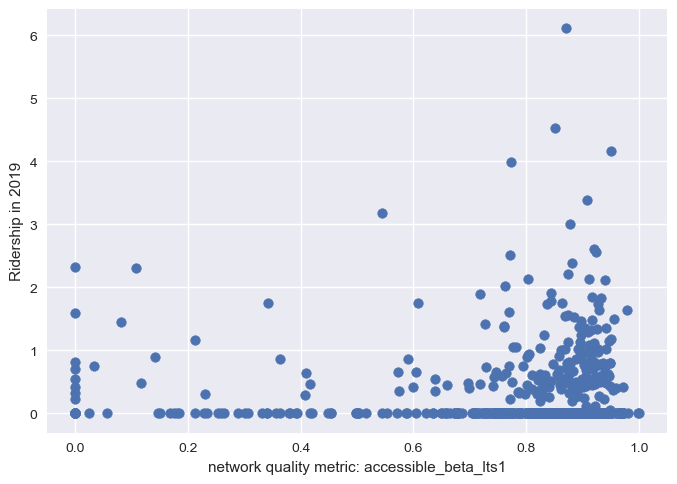

In [232]:
X=tracts[quality_variable_columns]
Y=tracts[[pct_bike_yr2,'pct_change']]

X_nonzero=ridership_quality_combined_nonzero[quality_variable_columns]
Y_nonzero=ridership_quality_combined_nonzero[[pct_bike_yr2,'pct_change']]

variable_to_use='accessible_beta_lts1' ## CHANGE THIS TO TRY OTHER QUALITY VARIABLES

plt.scatter(X[variable_to_use],Y[pct_bike_yr2])
plt.ylabel('Ridership in %s'%YEARS[1])
plt.xlabel('network quality metric: %s'%variable_to_use)

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

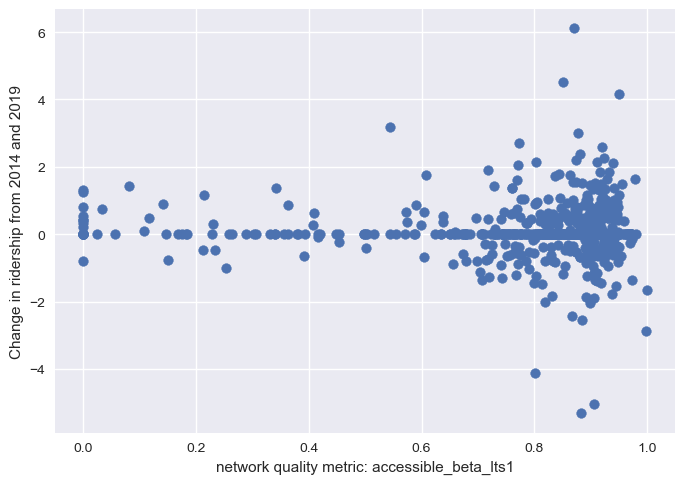

In [233]:
plt.scatter(X[variable_to_use],Y['pct_change'])
plt.ylabel('Change in ridership from %s and %s'%(YEARS[0],YEARS[1]))
plt.xlabel('network quality metric: %s'%variable_to_use)

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

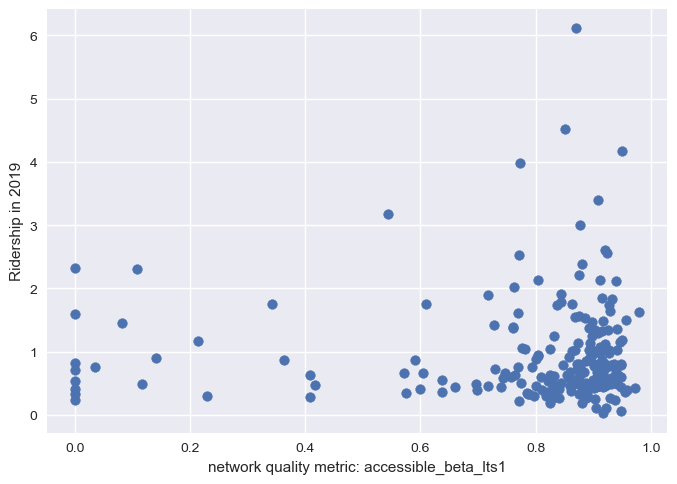

In [234]:
plt.scatter(X_nonzero[variable_to_use],Y_nonzero[pct_bike_yr2])
plt.ylabel('Ridership in %s'%YEARS[1])
plt.xlabel('network quality metric: %s'%variable_to_use)

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

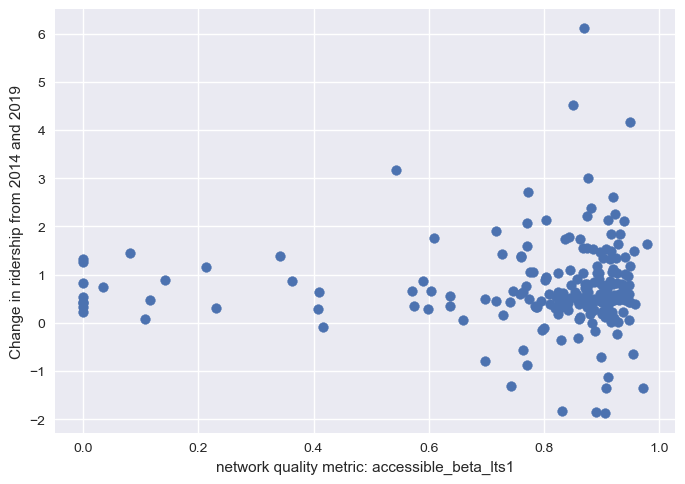

In [235]:
plt.scatter(X_nonzero[variable_to_use],Y_nonzero['pct_change'])
plt.ylabel('Change in ridership from %s and %s'%(YEARS[0],YEARS[1]))
plt.xlabel('network quality metric: %s'%variable_to_use)

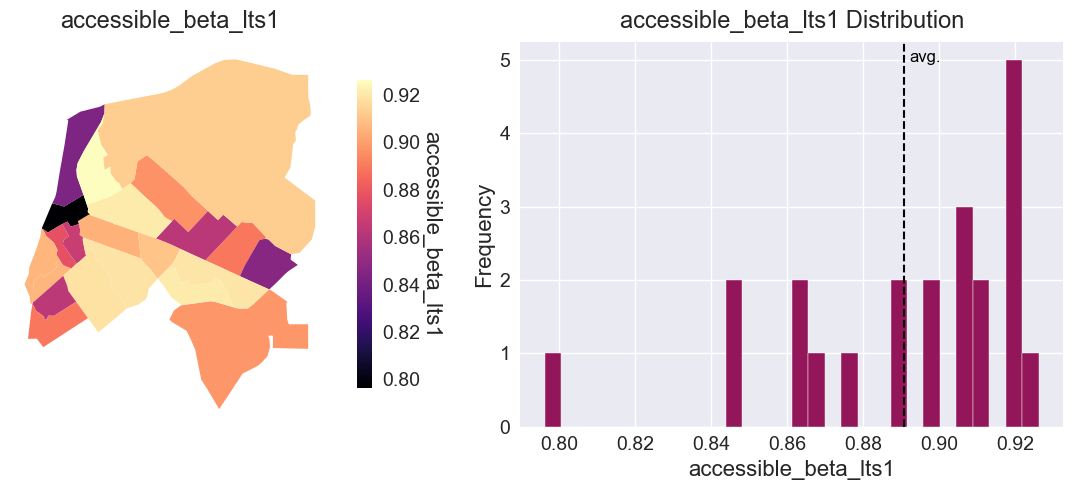

In [239]:
acquire.quick_viz(tracts[tracts['city']=='Concord'],variable_to_use)

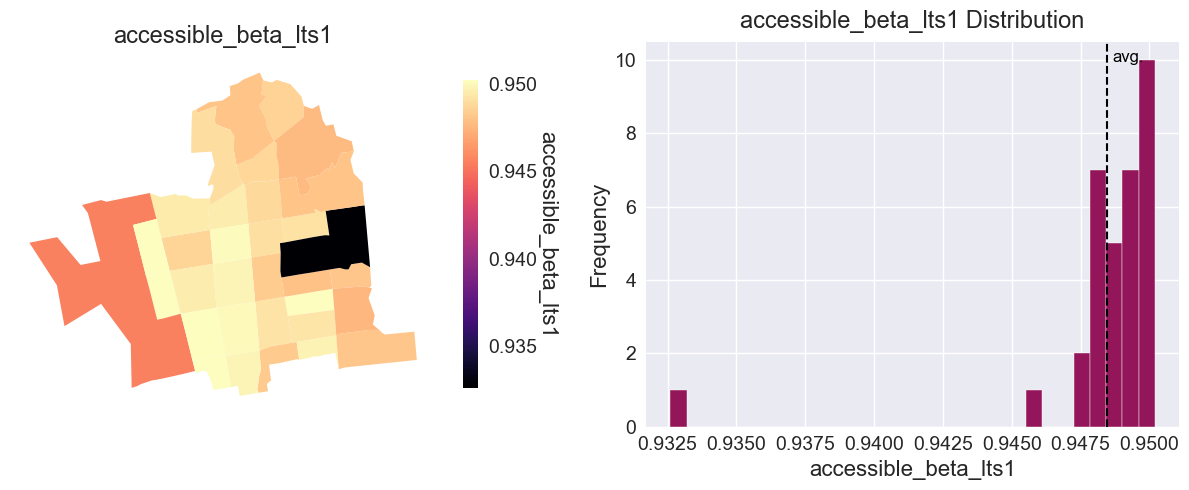

In [237]:
acquire.quick_viz(tracts[tracts['city']=='Berkeley'],variable_to_use)

(array([551.,  29.,  52.,  36.,  16.,  16.,  11.,   9.,   8.,   5.,   4.,
          3.,   3.,   0.,   1.,   1.,   1.,   0.,   0.,   1.,   1.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([0.        , 0.20372779, 0.40745557, 0.61118336, 0.81491114,
        1.01863893, 1.22236671, 1.4260945 , 1.62982228, 1.83355007,
        2.03727785, 2.24100564, 2.44473342, 2.64846121, 2.85218899,
        3.05591678, 3.25964456, 3.46337235, 3.66710013, 3.87082792,
        4.0745557 , 4.27828349, 4.48201127, 4.68573906, 4.88946684,
        5.09319463, 5.29692241, 5.5006502 , 5.70437798, 5.90810577,
        6.11183355]),
 <BarContainer object of 30 artists>)

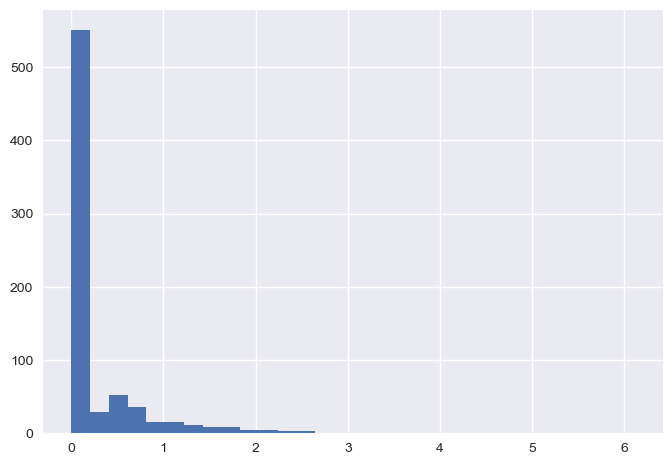

In [225]:
plt.hist(tracts['pct_bike_2019'],bins=30)